In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
assert np.__name__ == "numpy", f"Expected numpy, got {np.__name__}"

In [19]:
df_dnn = pd.read_csv("../data/processed/exp_run/dnn_exp.csv")
df_snn = pd.read_csv("../data/processed/exp_run/snn_exp.csv")
df_gru = pd.read_csv("../data/processed/exp_run/gru_exp.csv")
df_lstm = pd.read_csv("../data/processed/exp_run/lstm_exp.csv")

## All models Exp run Comparison

C:\Users\satis\AppData\Local\Temp\ipykernel_16740\1088864915.py:88: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\satis\OneDrive\Desktop\SEM-6\sem6\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


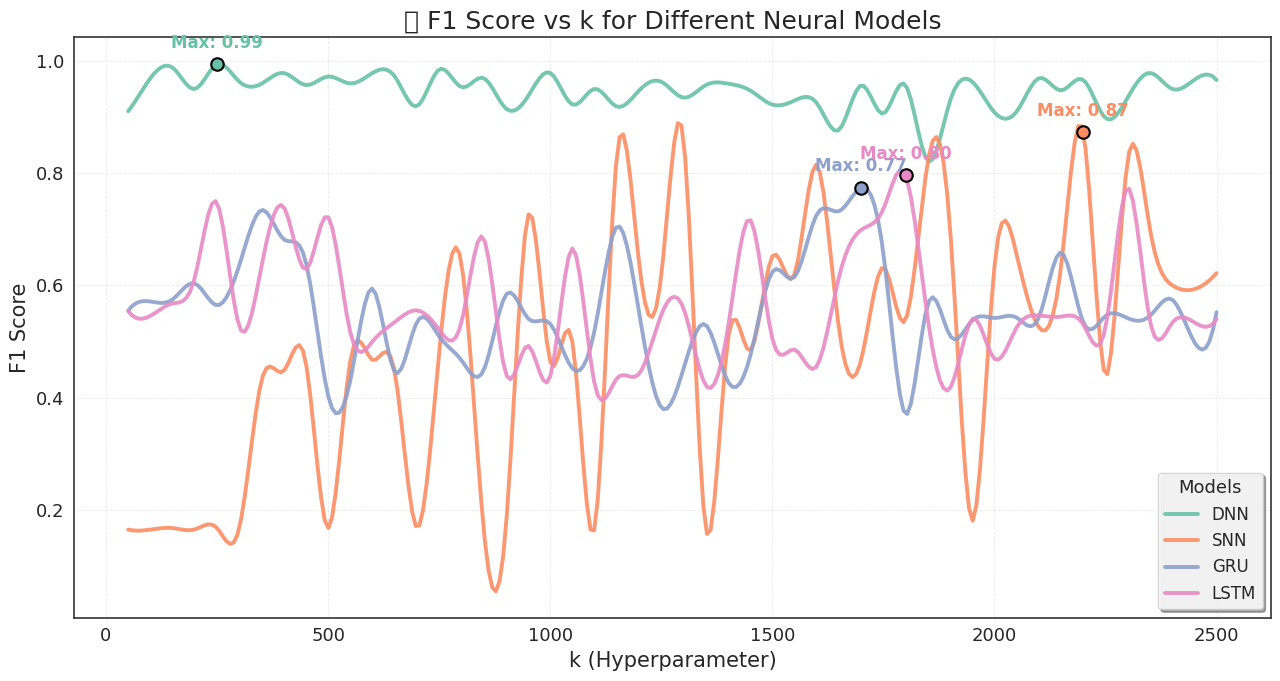

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'legend.fontsize': 12,
    'figure.titlesize': 20,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 1.2
})

# Load CSVs
df_dnn = pd.read_csv("../data/processed/exp_run/dnn_exp.csv")
df_snn = pd.read_csv("../data/processed/exp_run/snn_exp.csv")
df_gru = pd.read_csv("../data/processed/exp_run/gru_exp.csv")
df_lstm = pd.read_csv("../data/processed/exp_run/lstm_exp.csv")

# Choose the metric you want to visualize
y_metric = 'f1_score'  # Options: 'test_accuracy', 'precision', 'recall', 'f1_score', 'run_time', 'epochs_used'

# Smoothing function
def smooth_line(x, y, points=300):
    x = np.array(x)
    y = np.array(y)
    sorted_idx = np.argsort(x)
    x_sorted = x[sorted_idx]
    y_sorted = y[sorted_idx]
    
    if len(np.unique(x_sorted)) < 4:
        return x_sorted, y_sorted
    
    x_new = np.linspace(x_sorted.min(), x_sorted.max(), points)
    spline = make_interp_spline(x_sorted, y_sorted, k=3)
    y_smooth = spline(x_new)
    return x_new, y_smooth

# Color palette
colors = sns.color_palette("Set2", 4)
model_data = [
    (df_dnn, 'DNN', colors[0]),
    (df_snn, 'SNN', colors[1]),
    (df_gru, 'GRU', colors[2]),
    (df_lstm, 'LSTM', colors[3])
]

# Plotting
plt.figure(figsize=(13, 7))
for df, label, color in model_data:
    x = df['k']
    y = df[y_metric]
    x_smooth, y_smooth = smooth_line(x, y)

    # Smooth curve
    plt.plot(x_smooth, y_smooth, label=label, color=color, linewidth=2.8, alpha=0.9)
    
    # Max point annotation
    max_idx = y.idxmax()
    max_k = x[max_idx]
    max_val = y[max_idx]
    plt.plot(max_k, max_val, 'o', color=color, markersize=9, markeredgecolor='black', markeredgewidth=1.5)
    plt.annotate(f'Max: {max_val:.2f}', (max_k, max_val),
                 textcoords="offset points", xytext=(0,12), ha='center',
                 fontsize=12, color=color, weight='bold')

# Labels
title_map = {
    'test_accuracy': 'Test Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    'f1_score': 'F1 Score',
    'run_time': 'Run Time (s)',
    'epochs_used': 'Epochs Used'
}

plt.title(f'📊 {title_map.get(y_metric, y_metric)} vs k for Different Neural Models')
plt.xlabel('k (Hyperparameter)')
plt.ylabel(title_map.get(y_metric, y_metric))
plt.legend(title='Models', loc='best', fancybox=True, framealpha=0.85, frameon=True, shadow=True)
plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.4)
plt.tight_layout()
plt.show()


C:\Users\satis\AppData\Local\Temp\ipykernel_16740\139936937.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Max Accuracy', data=pd.DataFrame(max_vals), palette='Set2')


<Axes: xlabel='Model', ylabel='Max Accuracy'>

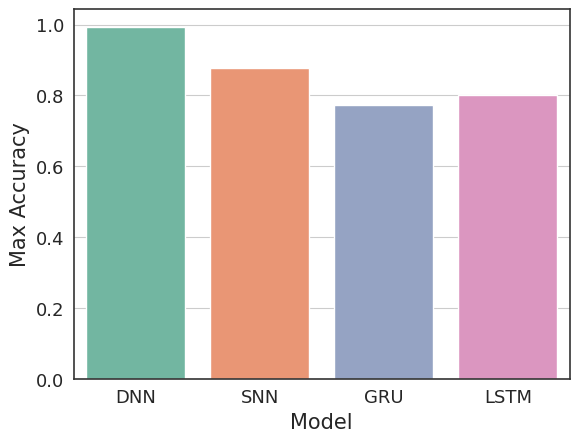

In [30]:
# Example for max accuracy bar plot
max_vals = {
    'Model': [],
    'Max Accuracy': []
}
for df, label in [(df_dnn, 'DNN'), (df_snn, 'SNN'), (df_gru, 'GRU'), (df_lstm, 'LSTM')]:
    max_vals['Model'].append(label)
    max_vals['Max Accuracy'].append(df['test_accuracy'].max())
sns.barplot(x='Model', y='Max Accuracy', data=pd.DataFrame(max_vals), palette='Set2')


<Axes: >

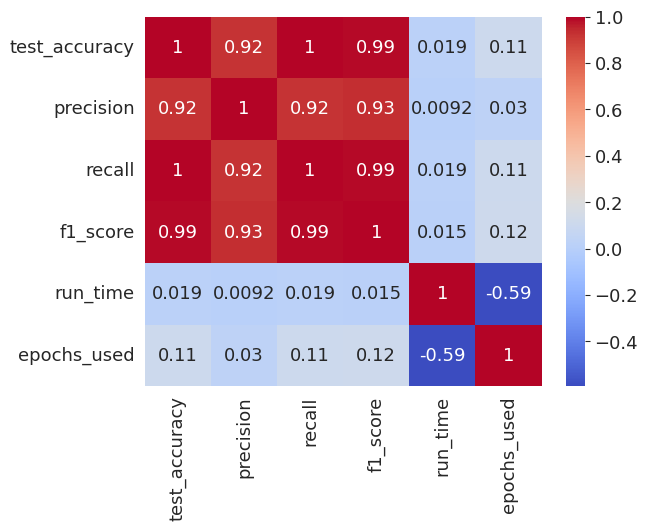

In [31]:
# Combine all models for a full overview
combined_df = pd.concat([df_dnn.assign(model='DNN'),
                         df_snn.assign(model='SNN'),
                         df_gru.assign(model='GRU'),
                         df_lstm.assign(model='LSTM')])

sns.heatmap(combined_df[['test_accuracy', 'precision', 'recall', 'f1_score', 'run_time', 'epochs_used']].corr(), 
            annot=True, cmap='coolwarm')


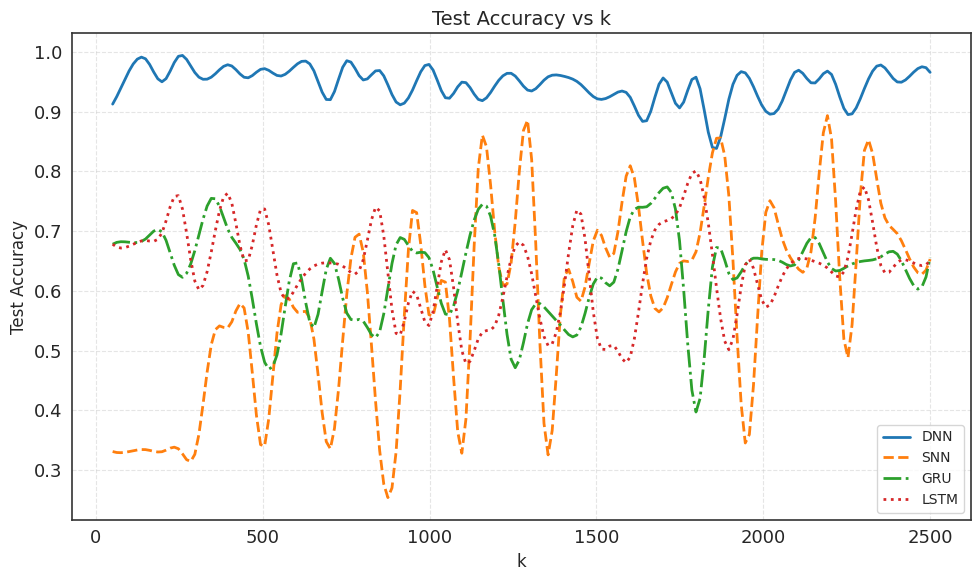

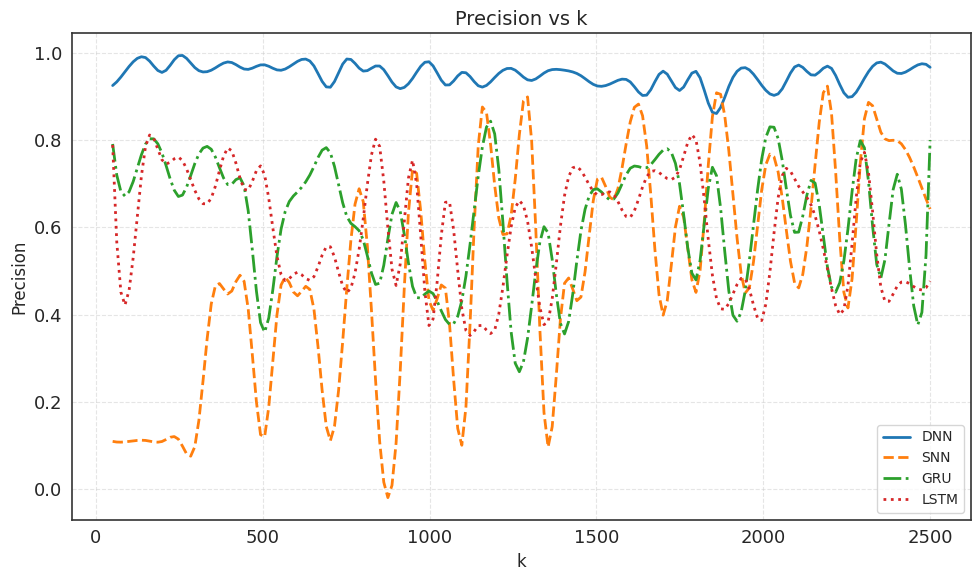

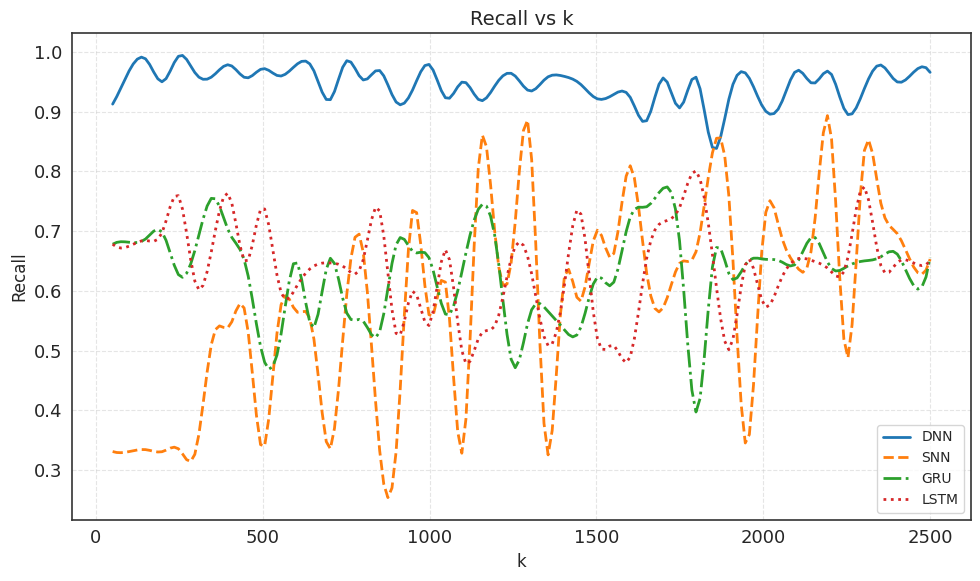

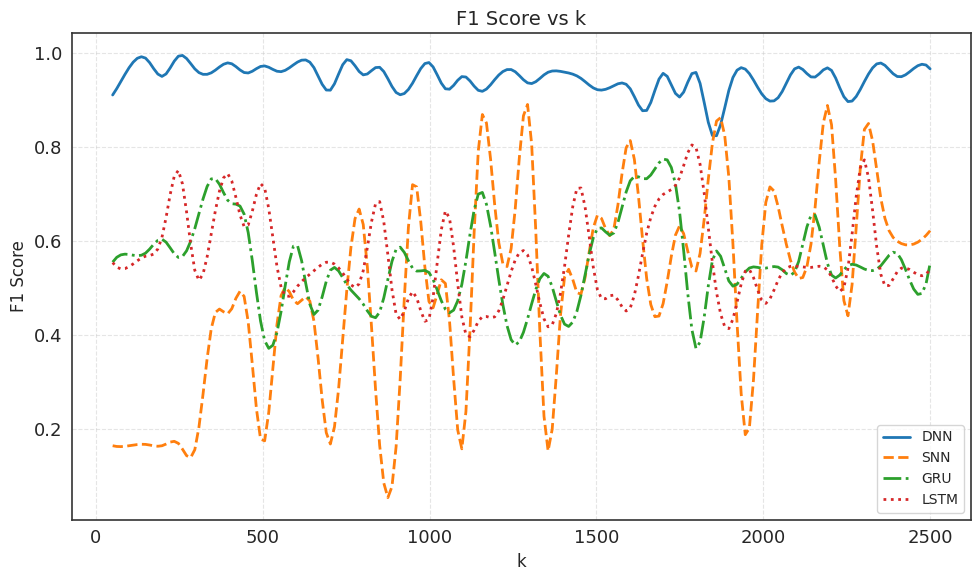

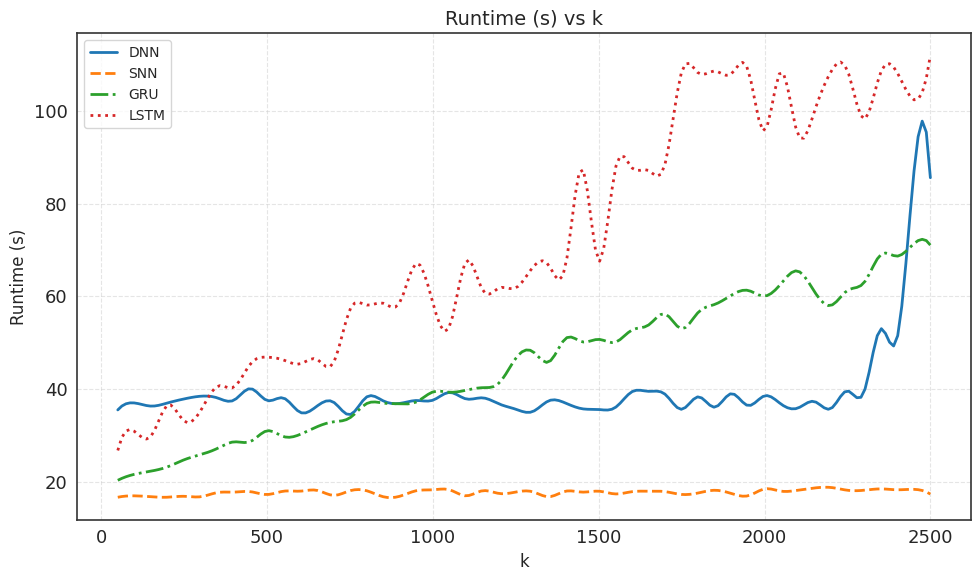

KeyError: 'epochs_used'

<Figure size 1000x600 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import numpy as np

# Smoothing function
def smooth_line(x, y, points=200):
    x = np.array(x)
    y = np.array(y)
    sorted_idx = np.argsort(x)
    x_sorted = x[sorted_idx]
    y_sorted = y[sorted_idx]

    if len(np.unique(x_sorted)) < 4:
        return x_sorted, y_sorted

    x_new = np.linspace(x_sorted.min(), x_sorted.max(), points)
    spline = make_interp_spline(x_sorted, y_sorted, k=3)
    y_smooth = spline(x_new)
    return x_new, y_smooth

# Metrics and titles
metrics = ['test_accuracy', 'precision', 'recall', 'f1_score', 'run_time', 'epochs_used']
titles = ['Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'Runtime (s)', 'Epochs Used']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
linestyles = ['-', '-', '-', '-']
models = [(df_dnn, 'DNN'), (df_snn, 'SNN'), (df_gru, 'GRU'), (df_lstm, 'LSTM')]

# Create individual plots for each metric
for idx, (metric, title) in enumerate(zip(metrics, titles)):
    plt.figure(figsize=(10, 6))  # Create a new figure for each metric
    for (df, label), color, style in zip(models, colors, linestyles):
        x = df['k']
        y = df[metric]
        x_smooth, y_smooth = smooth_line(x, y)
        plt.plot(x_smooth, y_smooth, label=label, color=color, linestyle=style, linewidth=2)
    
    plt.title(f'{title} vs k', fontsize=14)
    plt.xlabel('k', fontsize=12)
    plt.ylabel(title, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=10, loc='best')
    plt.tight_layout()
    plt.show()
